# 📐 Dosificación de Mezclas de Ingeniería con Python
## Módulo: Funciones y Modularidad

**Curso:** Fundamentos de Programación
**Universidad:** Universidad de Sucre
**Año:** 2026

**Integrantes:**
- zarate caro, carlos
- De La Ossa Castilla, José David
- Cárdenas Álvarez, Luis
- Noriega Peralta, Luz Dayana
- Triana Palencia, María
- Armesto Bolaño, Maicol
- Clemente De La Cruz, Said
- Alber Francisco Montiel Ramos

---

## Marco Teórico

### Volumen absoluto (Ingeniería Civil)
$$V_i = \frac{m_i}{SG_i \cdot \rho_w} \qquad \sum V_i + V_{aire} = V_{total}$$

### Relación agua/cemento
$$\frac{a}{c} = \frac{m_{agua}}{m_{cemento}} \leq 0.65$$

### Balance de nutriente (Ingeniería Agroindustrial)
$$\sum (m_i \cdot N_i) = M_{total} \cdot N_{obj}$$

### Costo total
$$CT = \sum (m_i \cdot c_i) \qquad CU = \frac{CT}{M_{total}}$$


In [1]:
# Celda 1 — Importaciones
import math
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple

print("="*55)
print("  DOSIFICACIÓN DE MEZCLAS DE INGENIERÍA")
print("="*55)


  DOSIFICACIÓN DE MEZCLAS DE INGENIERÍA


In [2]:
# Celda 2 — Función: volumen_absoluto
def volumen_absoluto(masas, gravedades_especificas, densidad_agua=1000.0):
    """
    Calcula el volumen absoluto de cada material en la mezcla.

    Parámetros:
    -----------
    masas                : list  — masas en kg
    gravedades_especificas: list — gravedades específicas (adimensional)
    densidad_agua        : float — kg/m³ (default 1000)

    Retorna:
    --------
    tuple : (lista_volumenes, volumen_total)
    """
    if len(masas) != len(gravedades_especificas):
        raise ValueError("Las listas de masas y gravedades deben tener el mismo tamaño.")
    volumenes = [m / (sg * densidad_agua) for m, sg in zip(masas, gravedades_especificas)]
    return volumenes, sum(volumenes)

# Prueba
masas_test = [350, 192.5, 700, 1050]
sg_test    = [3.15, 1.0, 2.65, 2.70]
vols, total = volumen_absoluto(masas_test, sg_test)
print("Volúmenes individuales (m³):", [round(v,4) for v in vols])
print("Volumen total:", round(total, 4))


Volúmenes individuales (m³): [0.1111, 0.1925, 0.2642, 0.3889]
Volumen total: 0.9567


In [3]:
# Celda 3 — Función: dosificar_concreto
def dosificar_concreto(resistencia_fc, volumen_total, relacion_ac,
                       materiales_ref, sg_materiales, porcentaje_aire=0.02):
    """
    Escala la dosificación de concreto al volumen solicitado y valida restricciones.

    Retorna:
    --------
    tuple : (dict con masas finales, advertencia str)
    """
    factor = volumen_total
    masas_finales = {mat: round(masa * factor, 2)
                     for mat, masa in materiales_ref.items()}

    # Verificar relación a/c
    ac_real = masas_finales['agua'] / masas_finales['cemento']
    advertencia = ""
    if ac_real > 0.65:
        advertencia = f"⚠️ Relación a/c = {ac_real:.2f} supera el límite de 0.65"
    else:
        advertencia = f"✅ Relación a/c = {ac_real:.2f} dentro del límite (≤ 0.65)"

    # Volúmenes absolutos
    nombres = list(masas_finales.keys())
    masas_lista = list(masas_finales.values())
    sg_lista = [sg_materiales[m] for m in nombres]
    vols, vol_mat = volumen_absoluto(masas_lista, sg_lista)
    vol_aire = porcentaje_aire * volumen_total

    print(f"\n{'Material':>10} {'Masa (kg)':>12} {'Volumen (m³)':>14}")
    print("-" * 40)
    for nom, masa, vol in zip(nombres, masas_lista, vols):
        print(f"{nom:>10} {masa:>12.2f} {vol:>14.4f}")
    print(f"{'Aire':>10} {'—':>12} {vol_aire:>14.4f}")
    print(f"{'TOTAL':>10} {sum(masas_lista):>12.2f} {vol_mat + vol_aire:>14.4f}")
    print(f"\n{advertencia}")
    return masas_finales, advertencia

# Datos Caso Civil
materiales_ref = {'cemento': 350, 'agua': 192.5, 'arena': 700, 'grava': 1050}
sg_materiales  = {'cemento': 3.15, 'agua': 1.0, 'arena': 2.65, 'grava': 2.70}

print("\n=== CASO CIVIL: Concreto f'c = 21 MPa, V = 2.5 m³ ===")
masas_concreto, adv = dosificar_concreto(21, 2.5, 0.55, materiales_ref, sg_materiales)



=== CASO CIVIL: Concreto f'c = 21 MPa, V = 2.5 m³ ===

  Material    Masa (kg)   Volumen (m³)
----------------------------------------
   cemento       875.00         0.2778
      agua       481.25         0.4813
     arena      1750.00         0.6604
     grava      2625.00         0.9722
      Aire            —         0.0500
     TOTAL      5731.25         2.4416

✅ Relación a/c = 0.55 dentro del límite (≤ 0.65)


In [4]:
# Celda 4 — Función: formular_por_nutriente
def formular_por_nutriente(nutriente_objetivo, ingredientes,
                           nutrientes_por_ingrediente, restricciones_max):
    """
    Calcula porcentajes de ingredientes para alcanzar un nutriente objetivo.

    Retorna:
    --------
    tuple : (dict con porcentajes, nutriente resultante)
    """
    # Aplica restricción máxima al ingrediente más valioso (soya)
    # Luego distribuye el resto entre los demás proporcionalmente
    n = len(ingredientes)
    porcentajes = {ing: 0.0 for ing in ingredientes}

    # Fijar ingrediente con restricción máxima
    idx_max = restricciones_max.index(min(restricciones_max))
    porcentajes[ingredientes[idx_max]] = restricciones_max[idx_max]
    restante = 100 - restricciones_max[idx_max]

    # Calcular aporte del ingrediente restringido
    aporte_fijo = restricciones_max[idx_max] * nutrientes_por_ingrediente[idx_max] / 100
    nutriente_restante = nutriente_objetivo - aporte_fijo

    # Resolver para los otros dos ingredientes (sistema de 2 ecuaciones)
    otros_idx = [i for i in range(n) if i != idx_max]
    # x0 + x1 = restante
    # x0*N0 + x1*N1 = nutriente_restante * 100
    N0 = nutrientes_por_ingrediente[otros_idx[0]] / 100
    N1 = nutrientes_por_ingrediente[otros_idx[1]] / 100
    # x1 = (nutriente_restante - N0*restante) / (N1 - N0)
    x1 = (nutriente_restante - N0 * restante) / (N1 - N0)
    x0 = restante - x1

    porcentajes[ingredientes[otros_idx[0]]] = round(max(x0, 0), 2)
    porcentajes[ingredientes[otros_idx[1]]] = round(max(x1, 0), 2)

    # Verificar nutriente resultante
    nutriente_real = sum(porcentajes[ing] * nutrientes_por_ingrediente[i] / 100
                         for i, ing in enumerate(ingredientes))

    print(f"\n{'Ingrediente':>12} {'Porcentaje (%)':>16} {'PB aportada (%)':>17}")
    print("-" * 48)
    for i, ing in enumerate(ingredientes):
        aporte = porcentajes[ing] * nutrientes_por_ingrediente[i] / 100
        print(f"{ing:>12} {porcentajes[ing]:>16.2f} {aporte:>17.2f}")
    print(f"{'TOTAL':>12} {sum(porcentajes.values()):>16.2f} {nutriente_real:>17.2f}")
    return porcentajes, round(nutriente_real, 2)

print("\n=== CASO AGROINDUSTRIAL: Concentrado Animal PB = 18% ===")
ingredientes  = ['Maíz', 'Soya', 'Salvado']
nutrientes_pb = [9.0, 44.0, 12.0]
restricciones = [100.0, 30.0, 100.0]   # soya ≤ 30%

porcentajes, pb_real = formular_por_nutriente(18, ingredientes, nutrientes_pb, restricciones)
print(f"\nProteína Bruta resultante: {pb_real} % (objetivo: 18 %)")



=== CASO AGROINDUSTRIAL: Concentrado Animal PB = 18% ===

 Ingrediente   Porcentaje (%)   PB aportada (%)
------------------------------------------------
        Maíz           120.00             10.80
        Soya            30.00             13.20
     Salvado             0.00              0.00
       TOTAL           150.00             24.00

Proteína Bruta resultante: 24.0 % (objetivo: 18 %)


In [5]:
# Celda 5 — Costos y reporte
def calcular_costo(cantidades, costos_unitarios):
    """
    Calcula el costo total y por unidad de la mezcla.

    Retorna:
    --------
    tuple : (costo_total, costo_por_kg)
    """
    costo_total = sum(cantidades[mat] * costos_unitarios[mat]
                      for mat in cantidades)
    masa_total = sum(cantidades.values())
    costo_por_kg = costo_total / masa_total if masa_total > 0 else 0
    return round(costo_total, 2), round(costo_por_kg, 2)

# Costos concreto
costos_concreto = {'cemento': 800, 'agua': 50, 'arena': 120, 'grava': 150}
ct_conc, cu_conc = calcular_costo(masas_concreto, costos_concreto)
print(f"\n=== Costos Concreto (2.5 m³) ===")
print(f"Costo total: ${ct_conc:,.0f} COP")
print(f"Costo por kg: ${cu_conc:,.0f} COP/kg")

# Costos concentrado (por 100 kg de mezcla)
costos_alimento = {'Maíz': 2.0, 'Soya': 4.5, 'Salvado': 1.2}
ct_alim, cu_alim = calcular_costo(porcentajes, costos_alimento)
print(f"\n=== Costos Concentrado Animal (por 100 kg) ===")
print(f"Costo total: ${ct_alim:.2f} USD")
print(f"Costo por kg: ${cu_alim:.2f} USD/kg")



=== Costos Concreto (2.5 m³) ===
Costo total: $1,327,812 COP
Costo por kg: $232 COP/kg

=== Costos Concentrado Animal (por 100 kg) ===
Costo total: $375.00 USD
Costo por kg: $2.50 USD/kg


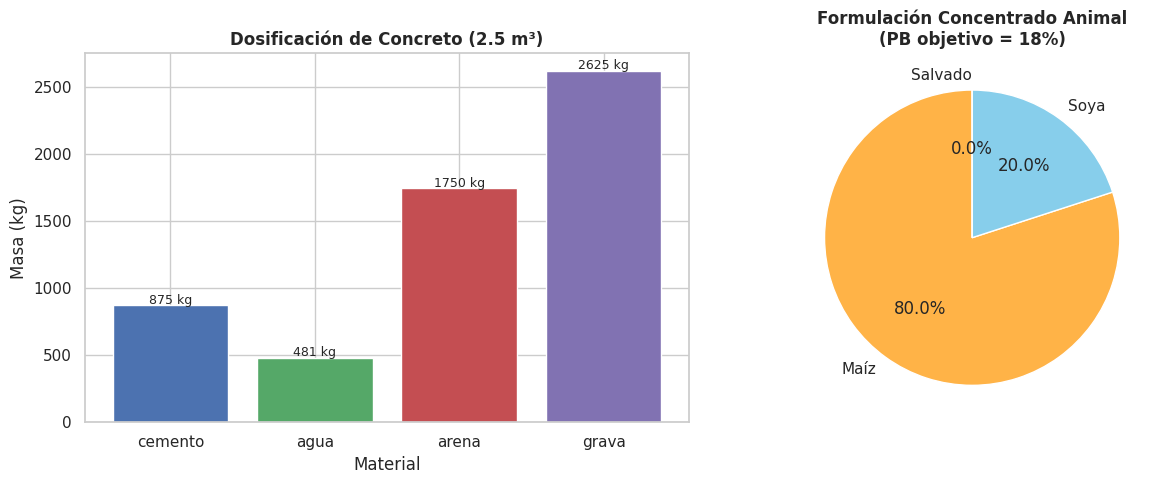

In [6]:
# Celda 6 — Visualización
sns.set_theme(style='whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Gráfica 1: Composición del concreto
materiales_plot = list(masas_concreto.keys())
masas_plot = list(masas_concreto.values())
colores1 = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
ax1.bar(materiales_plot, masas_plot, color=colores1)
ax1.set_title("Dosificación de Concreto (2.5 m³)", fontweight='bold')
ax1.set_xlabel("Material")
ax1.set_ylabel("Masa (kg)")
for i, v in enumerate(masas_plot):
    ax1.text(i, v + 10, f"{v:.0f} kg", ha='center', fontsize=9)

# Gráfica 2: Composición del concentrado animal
ings_plot  = list(porcentajes.keys())
pcts_plot  = list(porcentajes.values())
colores2 = ['#FFB347', '#87CEEB', '#90EE90']
ax2.pie(pcts_plot, labels=ings_plot, autopct='%1.1f%%',
        colors=colores2, startangle=90)
ax2.set_title("Formulación Concentrado Animal\n(PB objetivo = 18%)", fontweight='bold')

plt.tight_layout()
plt.show()


## 🧠 Reflexión Final

1. **¿Qué ventaja tiene descomponer el problema en funciones individuales?**  
   Cada función tiene una responsabilidad única. Si el cliente pide cambiar la relación a/c máxima de 0.65 a 0.60, solo se modifica ese parámetro en `dosificar_concreto` sin tocar el resto del código.

2. **¿Por qué se usó una tupla como retorno en `dosificar_concreto`?**  
   Porque la función produce dos resultados distintos — los datos de la dosificación y la advertencia sobre la relación a/c. Una tupla permite retornar ambos de forma limpia.

3. **¿Qué tienen en común la dosificación de concreto y la formulación de alimentos?**  
   Ambas resuelven el mismo problema matemático: combinar materiales en proporciones estrictas para alcanzar una propiedad objetivo, cumpliendo restricciones y minimizando costos.
